# _ Modeling Draft 4 _
* version sans l'hormone AMH 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

print(f"Shape → Train: {X_train.shape} | Test: {X_test.shape}")

Shape → Train: (1600, 20) | Test: (400, 20)


In [ ]:
excluded_features = [
    'Follicle No. (L)', 'Follicle No. (R)', 
    'Avg. F size (L) (mm)', 'Avg. F size (R) (mm)',
    'AMH(ng/mL)'
]

X_train_v3 = X_train.drop(columns=excluded_features, errors='ignore')
X_test_v3  = X_test.drop(columns=excluded_features, errors='ignore')

print(f"Nombre de features restantes : {X_train_v3.shape[1]}")
print("Features utilisées :", X_train_v3.columns.tolist())

Nombre de features restantes : 15
Features utilisées : ['Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)', 'Pimples(Y/N)', 'Hair loss(Y/N)', 'Cycle(R/I)', 'BMI', 'Waist:Hip Ratio', 'LH(mIU/mL)', 'FSH/LH', 'II    beta-HCG(mIU/mL)', 'Age (yrs)', 'Pregnant(Y/N)', 'Endometrium (mm)', 'Fast food (Y/N)']


In [4]:
models = {
    "LightGBM (Gradient Boosting)": LGBMClassifier(n_estimators=500, learning_rate=0.07, max_depth=7, random_state=42, verbose=-1),
    "Random Forest (Bagging)": RandomForestClassifier(n_estimators=400, max_depth=9, random_state=42),
    "Logistic Regression (Linéaire)": LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
}

results = []
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

for name, model in models.items():
    pipeline = Pipeline([('scaler', StandardScaler()), ('clf', model)])
    pipeline.fit(X_train_v3, y_train)
    
    y_pred = pipeline.predict(X_test_v3)
    y_prob = pipeline.predict_proba(X_test_v3)[:, 1]
    
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    cv_f1 = cross_val_score(pipeline, X_train_v3, y_train, cv=cv, scoring='f1').mean()
    
    results.append({
        'Modèle': name,
        'F1-Score': round(f1, 4),
        'ROC-AUC': round(auc, 4),
        'CV_F1': round(cv_f1, 4),
        'Gap': round(abs(f1 - cv_f1), 4)
    })
    
    print(f"{name:32} → F1: {f1:.4f} | AUC: {auc:.4f} | CV: {cv_f1:.4f} | Gap: {abs(f1 - cv_f1):.4f}")

LightGBM (Gradient Boosting)     → F1: 0.9837 | AUC: 0.9994 | CV: 0.9750 | Gap: 0.0088
Random Forest (Bagging)          → F1: 0.9496 | AUC: 0.9970 | CV: 0.9291 | Gap: 0.0204
Logistic Regression (Linéaire)   → F1: 0.7454 | AUC: 0.8972 | CV: 0.7538 | Gap: 0.0084


In [5]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='F1-Score', ascending=False).reset_index(drop=True)
results_df

,Modèle,F1-Score,ROC-AUC,CV_F1,Gap
0,LightGBM (Gradient Boosting),0.9837,0.9994,0.9750,0.0088
1,Random Forest (Bagging),0.9496,0.9970,0.9291,0.0204
2,Logistic Regression (Linéaire),0.7454,0.8972,0.7538,0.0084


In [ ]:
best_model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LGBMClassifier(n_estimators=500, learning_rate=0.07, max_depth=7, random_state=42, verbose=-1))
])

best_model.fit(X_train_v3, y_train)
y_pred = best_model.predict(X_test_v3)

print("\n" + "="*65)
print("RAPPORT DE CLASSIFICATION - LIGHTGBM (Version 3)")
print("="*65)
print(classification_report(y_test, y_pred))


RAPPORT DE CLASSIFICATION - LIGHTGBM (Version 3)
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       278
           1       0.98      0.99      0.98       122

    accuracy                           0.99       400
   macro avg       0.99      0.99      0.99       400
weighted avg       0.99      0.99      0.99       400



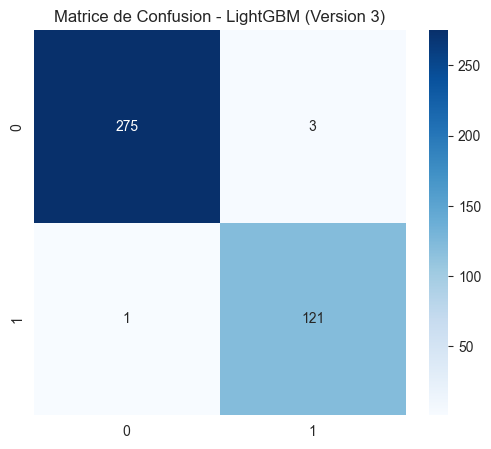

In [ ]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Matrice de Confusion - LightGBM (Version 3)')
plt.show()